# Personal Finance Analyzer


OBJECTIVE:
Analyze transaction data to uncover spending patterns, financial risks, and provide strategic recommendations.

PHASE 1 — DATA AUDIT & CLEANING

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# 1. Load the dataset and inspect structure:
df = pd.read_csv("dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   str    
 1   Transaction Description  1500 non-null   str    
 2   Category                 1500 non-null   str    
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   str    
dtypes: float64(1), str(4)
memory usage: 58.7 KB


In [3]:
df.head(1), df.tail(1)

(         Date Transaction Description      Category   Amount     Type
 0  2020-01-02             Score each.  Food & Drink  1485.69  Expense,
             Date            Transaction Description Category  Amount    Type
 1499  2024-12-29  Pressure activity defense detail.    Other  1480.0  Income)

In [4]:
# 2. Data Quality Checks:
df.isna().values.any(), df.isnull().values.any()

(np.False_, np.False_)

In [5]:
df.duplicated().any()

np.False_

In [6]:
(df["Amount"] < 0).any()

np.False_

In [7]:
df.groupby("Type").sum()

,Date,Transaction Description,Category,Amount
Type,,,,
Expense,2020-01-022020-01-022020-01-042020-01-132020-0...,Score each.Quality throughout.Instead ahead de...,Food & DrinkUtilitiesRentFood & DrinkShoppingF...,1227194.37
Income,2020-01-052020-01-192020-02-052020-02-082020-0...,Information last everything thank serve.Court ...,InvestmentOtherInvestmentOtherOtherInvestmentI...,734087.00


In [8]:
# 3. Date Handling:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df["Date"].isna().values.any(), df["Date"].isnull().values.any()

(np.False_, np.False_)

In [10]:
df["Year"] = df["Date"].dt.year

In [11]:
df["Month"] = df["Date"].dt.month

In [12]:
years = df["Year"]
years.unique()

array([2020, 2021, 2022, 2023, 2024], dtype=int32)

In [13]:
months = df["Month"]
months.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [14]:
df["Month-Year"] = df["Date"].dt.to_period('M')

In [15]:
mounts_years = df["Month-Year"]
mounts_years.unique()

<PeriodArray>
['2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06', '2020-07',
 '2020-08', '2020-09', '2020-10', '2020-11', '2020-12', '2021-01', '2021-02',
 '2021-03', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09',
 '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03', '2022-04',
 '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11',
 '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06',
 '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01',
 '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08',
 '2024-09', '2024-10', '2024-11', '2024-12']
Length: 60, dtype: period[M]

## Questions
What is the time span of the dataset? - 2020-01 to 2024-12

Are there any suspicious dates? - No

Is the dataset complete across months? - Yes

In [16]:
# 4. Data Validation Rules:
# Check the types
types_of_expenses = df["Type"]
types_of_expenses.unique()

<StringArray>
['Expense', 'Income']
Length: 2, dtype: str

In [17]:
# Check the values (must be only positive)
(df["Amount"] <= 0).any()

np.False_

Check if the types have relatively valid data

In [18]:
group_expenses = df[df["Type"] == "Expense"]["Amount"]
group_expenses.mean(), group_expenses.std(), group_expenses.count(), group_expenses.max(), group_expenses.min()

(np.float64(1004.2507119476269),
 np.float64(571.5369855807377),
 np.int64(1222),
 np.float64(1999.82),
 np.float64(14.37))

Expenses mean is 1004, std is 571, so 2std = 2146, that means max number 1999 is not outliner same with min -2std=-138

In [19]:
group_incomes = df[df["Type"] == "Income"]["Amount"]
group_incomes.mean(), group_incomes.std(), group_incomes.count(), group_incomes.max(), group_incomes.min()

(np.float64(2640.6007194244603),
 np.float64(1261.8904142661554),
 np.int64(278),
 np.float64(4996.0),
 np.float64(500.0))

Income mean is 2640, std is 1261, so 2std = 5162, that means max number 4996 is not outliner same with min -2std=-118

In [20]:
# What is the most and min amount of transactions in a day?
daily_counts = df.groupby('Date').size()
daily_counts.min(), daily_counts.max()

(np.int64(1), np.int64(6))

In [21]:
category_count = df.groupby("Category")["Amount"].sum()
category_combined = df.groupby("Category").size()
category_count, category_combined

(Category
 Entertainment       148165.47
 Food & Drink        159493.39
 Health & Fitness    145194.06
 Investment          363252.00
 Other               370835.00
 Rent                162075.39
 Salary              149053.55
 Shopping            146880.75
 Travel              169497.79
 Utilities           146833.97
 Name: Amount, dtype: float64,
 Category
 Entertainment       143
 Food & Drink        149
 Health & Fitness    152
 Investment          142
 Other               136
 Rent                165
 Salary              146
 Shopping            150
 Travel              160
 Utilities           157
 dtype: int64)

5. Deliverable

1) Short brief summary

. Dataset contains both Income and Expense transactions.

. No negative or zero Amount values detected.

. No global statistical outliers using 2 standard deviation rule.

. Daily transaction counts range from 1 to 6 (realistic behavior).

. No immediate impossible transaction frequency patterns detected.

2) Cleaning Actions Performed

.Converted Date column to datetime format.

.Verified sign consistency between Type and Amount.

.Validated transaction frequency per day.

.Checked for statistical outliers globally.

3) Assumptions Made
 
.Dataset likely represents a mixed income profile (investment + salary + other).

.Income and Expense values are stored as positive numbers; direction is defined by Type column.

.Large income values (up to ~5000) are considered valid based on statistical boundaries.

.No abnormal behavioral spikes detected at daily level.

# PHASE 2 — SPENDING STRUCTURE ANALYSIS

In [22]:
# 1. Total Spending Per Category
only_expenses = df[df["Type"] == "Expense"]
expenses_categories = pd.DataFrame(only_expenses.groupby("Category")["Amount"].sum().reset_index())
expenses_categories = expenses_categories.sort_values(ascending=False, by="Amount")

In [23]:
# Interesting to see
salary_only_expenses = only_expenses[only_expenses["Category"] == "Salary"]
salary_only_expenses

,Date,Transaction Description,Category,Amount,Type,Year,Month,Month-Year
11,2020-01-26,Range successful simply.,Salary,1077.09,Expense,2020,1,2020-01
27,2020-02-13,Building different full open.,Salary,294.31,Expense,2020,2,2020-02
58,2020-04-06,Away third.,Salary,493.56,Expense,2020,4,2020-04
61,2020-04-17,Government nice.,Salary,1729.04,Expense,2020,4,2020-04
74,2020-05-03,I fast camera inside.,Salary,318.05,Expense,2020,5,2020-05
...,...,...,...,...,...,...,...,...
1458,2024-11-13,Dinner rich decide do.,Salary,1950.21,Expense,2024,11,2024-11
1468,2024-11-19,Bit need allow.,Salary,606.22,Expense,2024,11,2024-11
1478,2024-11-25,Red republican father party.,Salary,383.70,Expense,2024,11,2024-11
1481,2024-11-30,Project at risk.,Salary,1456.94,Expense,2024,11,2024-11


In [24]:
total_spending = expenses_categories["Amount"].sum()
expenses_categories["% from Total"] = (expenses_categories["Amount"] / total_spending) * 100
expenses_categories

,Category,Amount,% from Total
6,Travel,169497.79,13.811813
3,Rent,162075.39,13.206986
1,Food & Drink,159493.39,12.996587
4,Salary,149053.55,12.145880
0,Entertainment,148165.47,12.073513
5,Shopping,146880.75,11.968825
7,Utilities,146833.97,11.965013
2,Health & Fitness,145194.06,11.831383


Visualization

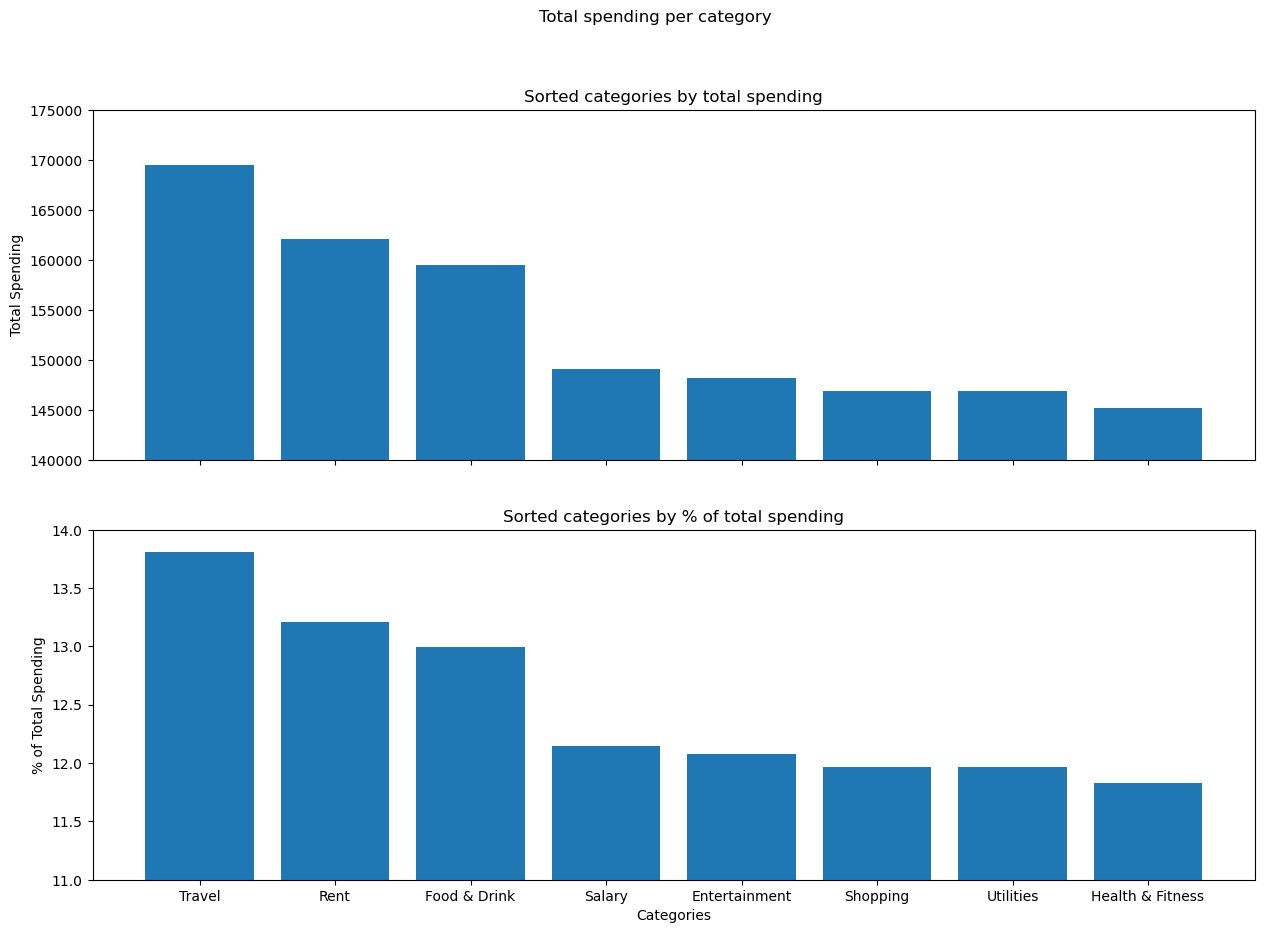

In [25]:
fig, (ax0, ax1) = plt.subplots(figsize=(15,10), nrows=2, ncols=1, sharex=True)

fig.suptitle("Total spending per category")

ax0.bar(x=expenses_categories["Category"],
        height=expenses_categories["Amount"])

ax0.set_ylim(140000,175000)

ax0.set(title="Sorted categories by total spending",
        ylabel="Total Spending")

ax1.set_ylim(11,14)

ax1.bar(x=expenses_categories["Category"],
        height=expenses_categories["% from Total"])

ax1.set(title="Sorted categories by % of total spending",
        ylabel="% of Total Spending",
        xlabel="Categories");

Questions:
- What are the top 3 spending categories? - Travel, Rent, Food & Drink
- Does one category dominate spending? - Relatively no, the max spending is travel with 13.8%
- Is spending diversified or concentrated? - Diversified

In [26]:
# 2. Frequency vs Average Transaction Analysis
# All counts made only on expenses
transaction_count_per_category = only_expenses.groupby("Category").size()
mean_of_transaction_for_every_category = only_expenses.groupby("Category")["Amount"].mean()
transaction_count_per_category ,mean_of_transaction_for_every_category

(Category
 Entertainment       143
 Food & Drink        149
 Health & Fitness    152
 Rent                165
 Salary              146
 Shopping            150
 Travel              160
 Utilities           157
 dtype: int64,
 Category
 Entertainment       1036.122168
 Food & Drink        1070.425436
 Health & Fitness     955.224079
 Rent                 982.275091
 Salary              1020.914726
 Shopping             979.205000
 Travel              1059.361188
 Utilities            935.248217
 Name: Amount, dtype: float64)

In [27]:
summary_transaction_table = pd.DataFrame(only_expenses["Category"].unique(), columns=["Category"])
summary_transaction_table = summary_transaction_table.set_index("Category")
summary_transaction_table["Transaction count"] = transaction_count_per_category
summary_transaction_table["Average transaction size"] = mean_of_transaction_for_every_category
summary_transaction_table = summary_transaction_table.sort_values(ascending=False, by="Transaction count")
summary_transaction_table = summary_transaction_table.reset_index()
summary_transaction_table

,Category,Transaction count,Average transaction size
0,Rent,165,982.275091
1,Travel,160,1059.361188
2,Utilities,157,935.248217
3,Health & Fitness,152,955.224079
4,Shopping,150,979.205000
5,Food & Drink,149,1070.425436
6,Salary,146,1020.914726
7,Entertainment,143,1036.122168


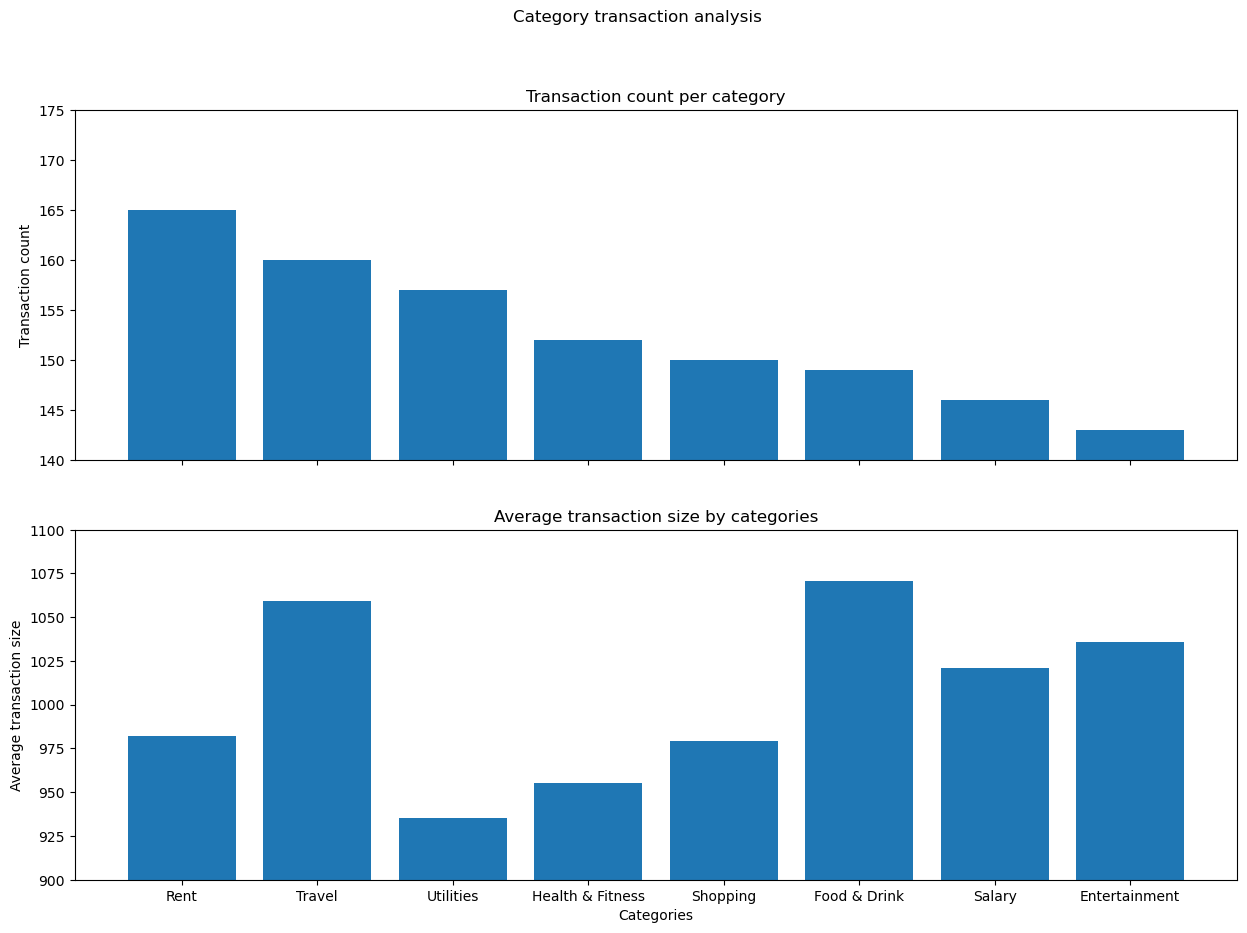

In [28]:
fig, (ax0, ax1) = plt.subplots(figsize=(15,10), nrows=2, ncols=1, sharex=True)

fig.suptitle("Category transaction analysis")

ax0.bar(x=summary_transaction_table["Category"],
        height=summary_transaction_table["Transaction count"])

ax0.set_ylim(140,175)

ax0.set(title="Transaction count per category",
        ylabel="Transaction count")

ax1.set_ylim(900,1100)

ax1.bar(x=summary_transaction_table["Category"],
        height=summary_transaction_table["Average transaction size"])

ax1.set(title="Average transaction size by categories",
        ylabel="Average transaction size",
        xlabel="Categories");

Questions:

- Which categories are frequent small expenses? - Utilities
- Which are rare but expensive? - Entertainment
- Which behavior pattern is riskier? - Many transactions in the rent category

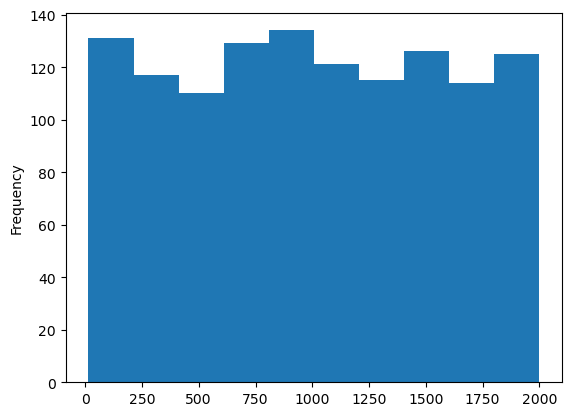

In [29]:
# 3. Spending Distribution Analysis

only_expenses_amounts = only_expenses["Amount"]
only_expenses_amounts.plot.hist();

Questions:
- Are most transactions small? - No 
- Are large transactions rare? - No
- Is spending right-skewed (typical financial pattern)? - Uniform

The histogram shows a near-uniform distribution of expenses, which is unusual for real financial data. In real-world spending behavior, transaction amounts typically follow a log-normal (right-skewed) distribution, where many small purchases occur frequently while large expenses such as rent occur rarely. The observed uniform pattern suggests the dataset may have been synthetically generated using a uniform random distribution rather than reflecting natural consumer behavior.

In [30]:
# 4. Category Volatility Analysis

std_of_transactions = only_expenses.groupby("Category")["Amount"].std()
coefficient_of_variation = std_of_transactions / mean_of_transaction_for_every_category

summary_transaction_table = summary_transaction_table.set_index("Category")
summary_transaction_table["Std of transactions amount"] = std_of_transactions
summary_transaction_table["Coefficient of variation"] = coefficient_of_variation
summary_transaction_table = summary_transaction_table.reset_index()
summary_transaction_table

,Category,Transaction count,Average transaction size,Std of transactions amount,Coefficient of variation
0,Rent,165,982.275091,548.040691,0.557930
1,Travel,160,1059.361188,546.564958,0.515938
2,Utilities,157,935.248217,582.773911,0.623122
3,Health & Fitness,152,955.224079,588.302857,0.615879
4,Shopping,150,979.205000,552.475315,0.564208
5,Food & Drink,149,1070.425436,600.049597,0.560571
6,Salary,146,1020.914726,593.111690,0.580961
7,Entertainment,143,1036.122168,559.549525,0.540042


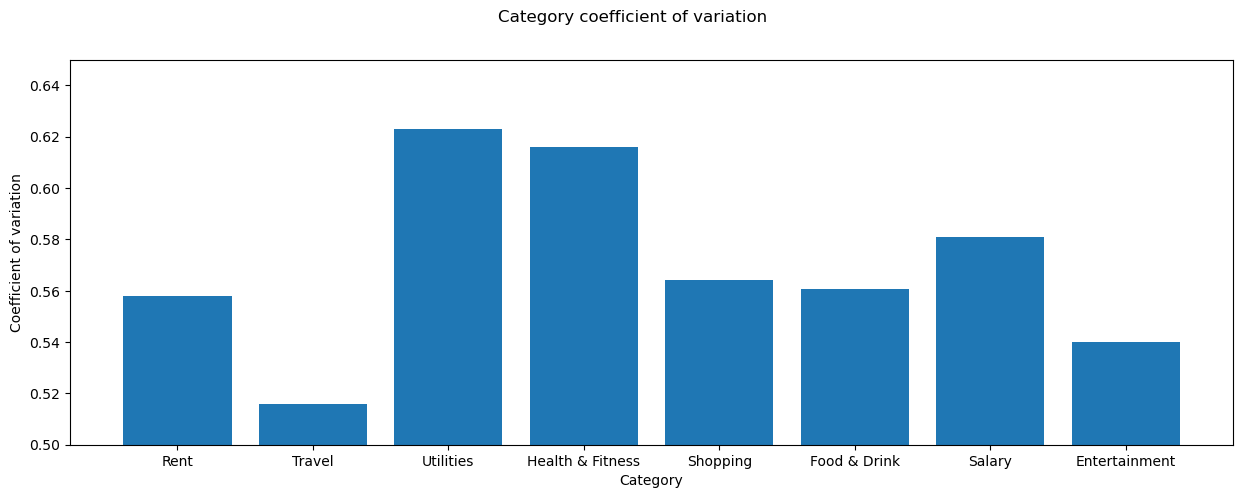

In [31]:
fig, ax = plt.subplots(figsize=(15,5))

fig.suptitle("Category coefficient of variation")

ax.bar(x=summary_transaction_table["Category"],
        height=summary_transaction_table["Coefficient of variation"])

ax.set_ylim(0.5, 0.65)

ax.set( xlabel="Category",
        ylabel="Coefficient of variation");

Questions:
- Which categories have unpredictable spending? - Non
- Are high-volatility categories also high-total categories? - No
- Where is financial risk concentrated? - No risk
- 
The coefficient of variation across categories appears nearly identical, suggesting that transaction amounts are drawn from a single underlying distribution regardless of category. In real financial datasets, different spending categories typically exhibit distinct variability patterns. For example, rent is usually highly stable while food and entertainment expenses fluctuate more frequently. This uniform volatility pattern further supports the conclusion that the dataset is synthetically generated.

# PHASE 3 — TIME-BASED TREND ANALYSIS

In [32]:
# Calculate expenses
monthly_total_spending = only_expenses.groupby("Month-Year")["Amount"].sum()
monthly_transaction_count = only_expenses.groupby("Month-Year")["Amount"].count()
monthly_average_transaction = only_expenses.groupby("Month-Year")["Amount"].mean()

# Convert to timestamp
monthly_total_spending.index = monthly_total_spending.index.to_timestamp()
monthly_transaction_count.index = monthly_transaction_count.index.to_timestamp()

In [33]:
# Calculate incomes
only_income = df[df["Type"] == "Income"]
monthly_total_income = only_income.groupby("Month-Year")["Amount"].sum()

monthly_total_income.index = monthly_total_income.index.to_timestamp()

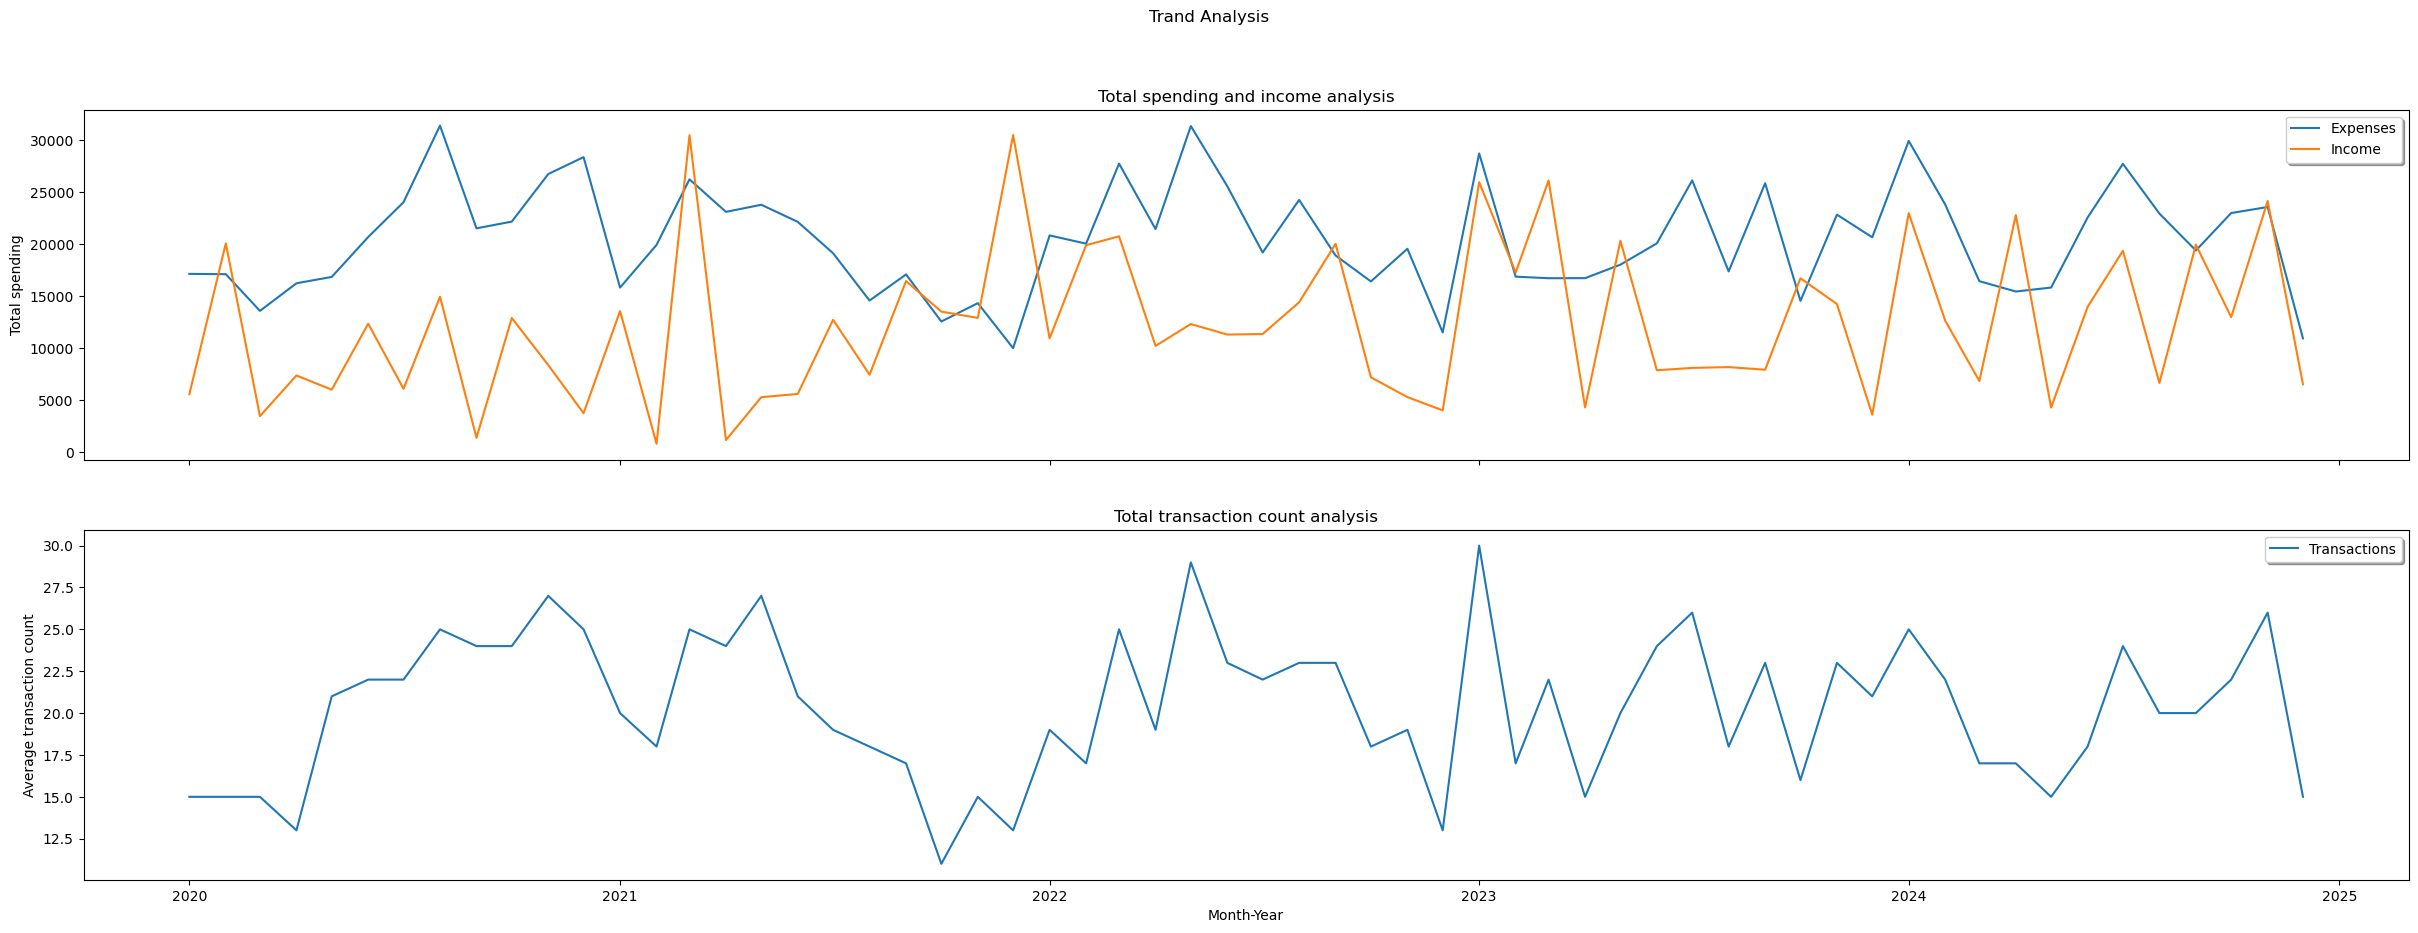

In [34]:
# Visualization
fig, (ax0, ax1) = plt.subplots(figsize=(30,10), nrows=2, ncols=1, sharex=True)

fig.suptitle("Trand Analysis")

ax0.plot(monthly_total_spending.index,
         monthly_total_spending.values,
         label="Expenses")

ax0.plot(monthly_total_income.index,
         monthly_total_income.values,
         label="Income")

ax0.legend(loc='upper right', shadow=True)

ax0.set(title="Total spending and income analysis",
        ylabel="Total spending")



ax1.plot(monthly_transaction_count.index,
         monthly_transaction_count.values,
         label="Transactions")

ax1.legend(loc='upper right', shadow=True)

ax1.set(title="Total transaction count analysis",
        ylabel="Average transaction count",
        xlabel="Month-Year");

Questions:
- Is spending increasing over time? - Stable
- Are there seasonal patterns? - Low spending in the end or start of the year, high spending in the summer
- Are there spikes indicating instability? - No

# PHASE 4 — FINANCIAL RISK & ANOMALY DETECTION

In [53]:
# Is there aany anmally big expenses? x > 2std
mean_expenses = only_expenses["Amount"].mean()
std_expenses = only_expenses["Amount"].std()
threshold = mean_expenses + 2 * std_expenses
outliers = only_expenses[only_expenses["Amount"] > threshold]
# Combine
outliers["Month-Year"] = outliers["Date"].dt.to_period("M")
monthly_anomalies = outliers.groupby("Month-Year").size()

In [46]:
# Identify high-volatility months
monthly_volaility = only_expenses.groupby("Month-Year")["Amount"].std()
monthly_volaility_std = monthly_volaility.std()
monthly_volaility_mean = monthly_volaility.mean()
threshold = monthly_volaility_mean + 2 *monthly_volaility_std
monthly_volaility_outliers = monthly_volaility[monthly_volaility > threshold]
monthly_volaility_outliers

Month-Year
2023-12    728.975482
Freq: M, Name: Amount, dtype: float64

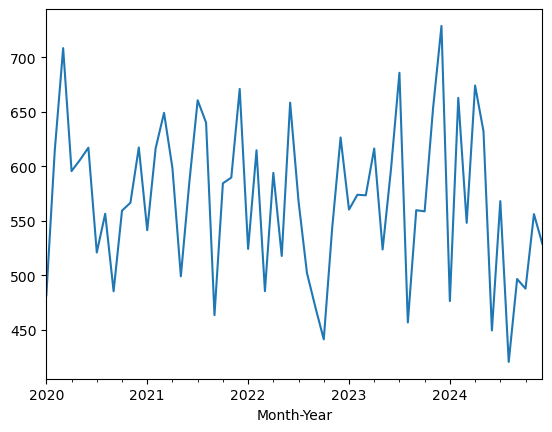

In [63]:
# Plot of monthly volaility over time
monthly_volaility.plot();

In [61]:
risk_df = pd.DataFrame({"volatility": monthly_volaility_outliers, "anomalies": monthly_anomalies}).fillna(0)
risk_df["risk_score"] = risk_df["volatility"] + risk_df["anomalies"]

In [58]:
risk_df

,volatility,anomalies,risk_score
Month-Year,,,
2023-12,728.975482,0.0,728.975482


Questions:
- When does financial instability peak? - 2023-12
- Are anomalies isolated or clustered? - no anomalies
- Is risk trending upward? - stable

The financial risk analysis shows very stable spending behavior across the dataset. Only one month exhibited slightly higher volatility, and no transactions were detected as anomalies based on the statistical threshold.
This suggests that spending patterns remain consistent over time without significant financial shocks or instability. The lack of anomalies and the similar behavior across categories also indicates that the dataset is likely synthetically generated rather than reflecting real financial activity.

# PHASE 5 — STRATEGIC CONSULTING RECOMMENDATIONS

## Executive Summary

This financial transaction analysis examines spending behavior, financial stability, and potential risk patterns using historical transaction data. The objective of the analysis is to identify key spending drivers, evaluate financial volatility, and provide strategic recommendations for improving financial management.

The analysis shows that the largest share of expenses is concentrated in **Traveling**, followed by **Rent** and **Food & Drink**. Together, these categories represent the primary drivers of total spending. The category **Rent** shows the highest number of transactions, indicating frequent day-to-day spending activity. In contrast, **Food & Drink** contains the largest average transaction value, suggesting larger but less frequent purchases.

Spending distribution analysis indicates that most transactions fall within the range of **0-2000**(Sintetic Data), while larger expenses appear less frequently. Volatility analysis shows that **Utilities** demonstrates the highest variability in transaction values, suggesting less predictable spending behavior. Monthly volatility analysis indicates that financial instability peaks during **2023-12**, though overall financial behavior remains relatively stable throughout the observed period.

Anomaly detection did not reveal significant outlier transactions exceeding the defined statistical threshold. This indicates that spending activity remains within expected boundaries and does not show evidence of extreme financial events within the dataset.

### Strategic Recommendations

1. **Cost Optimization**
   Since **Traveling** represents the largest share of expenses, monitoring and optimizing spending in this category could produce the greatest financial impact.

2. **Spending Stability Improvement**
   The category **Utilities** shows higher variability compared to other spending categories. Introducing budgeting limits or tracking mechanisms could help stabilize spending in this area.

3. **Financial Monitoring System**
   Implementing continuous monitoring of transaction activity would allow early detection of unusual financial behavior and support better long-term financial planning.

### Short-Term Actions

* Review spending patterns in **Traveling** and identify opportunities to reduce unnecessary expenses.
* Monitor monthly spending variability, particularly during **2023-12**.
* Track frequent transactions within **Utilites** to identify habitual spending.

### Long-Term Actions

* Develop a structured budgeting framework focused on controlling high-impact categories.
* Implement automated financial tracking tools to monitor spending trends over time.
* Use historical transaction patterns to build predictive models for future financial planning.

Overall, the analysis highlights the main spending drivers, identifies areas of financial variability, and outlines actionable steps to improve spending efficiency and long-term financial stability.

### Dataset Summary

The analysis in this project was conducted using a transaction dataset containing information about dates, transaction descriptions, spending categories, transaction amounts, and transaction types (income or expense). The dataset was treated as a typical personal financial record similar to what a client might provide for financial analysis.

During the exploratory analysis, several patterns suggested that the dataset is synthetically generated rather than representing real financial activity. In particular, many spending categories exhibited very similar statistical properties, such as comparable levels of volatility and uniform transaction distributions. In real-world financial data, different categories usually show distinct behavioral patterns—for example, fixed expenses like rent tend to have very low variability, while discretionary categories such as entertainment typically fluctuate more.

Additionally, anomaly detection and volatility analysis revealed relatively uniform transaction behavior, with few extreme events and minimal differences across time periods. This further supports the conclusion that the data likely follows randomly generated distributions rather than natural human spending behavior.

Despite these limitations, the dataset was still useful for demonstrating a complete financial analysis workflow, including data validation, spending distribution analysis, behavioral insights, volatility measurement, and financial risk assessment. The methods applied in this project reflect standard analytical techniques used in financial analytics and provide a strong foundation for working with real-world financial data.
